# Estadisitca II - Grupo #9.

Realizado por:
*   Angela Lozano Pulido - 2221913
*   Anyi Lorena Villabona Roa - 2215163

[CALCULADORA](https://statisticscalculators.com/hypothesis-test-calculator/)


#Funciones utilizadas

In [ ]:
# ========== LIBRERIAS ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import t
from google.colab import drive
import os
from glob import glob
import seaborn as sns

#Conectar con mi drive
drive.mount('/content/drive')

Mounted at /content/drive


##PH Dos Poblaciones: Varianza Desconocida

In [ ]:
def PHDP_VarDesconocida(x1, x2, delta_0, delta_real, n1, n2, s1_2, s2_2, alfa, cola, tipo_desviación):
  if tipo_desviación == 'igual':
    print('Tipo de varianza: igual')

    #Sp2: varianza poblacional s**2 obtenida con las desviaciones muestrales (s) y otros datos
    s1= np.sqrt(s1_2)
    s2= np.sqrt(s2_2)

    sp2= ((n1-1)*(s1_2)+(n2-1)*(s2_2))/(n1+n2-2)
    sp= np.sqrt(sp2)
    print(f'Vaianza poblacional obtenida: sp2= {sp2:.3f}')
    print(f'Desviación estándar a trabajar: sp= {sp:.3f}')

    v= n1+n2-2
    print(f'Grados de libertad: v= {v:.3f}')

    #Zo
    zo= (x1-x2-delta_0)/(sp*np.sqrt((1/n1)+(1/n2)))
    print(f'Estadístico de prueba: zo= {zo:.3f}')
    x= np.linspace(-4, 4, 100)
    y= norm.pdf(x, 0, 1)

  elif tipo_desviación == 'diferente':
    print('Tipo de varianza: diferente')

    #to
    zo= (x1-x2-delta_0)/(np.sqrt(((s1_2/n1)+(s2_2/n2))))
    print(f'Estadístico de prueba: to= {zo:.3f}')
    x= np.linspace(-4, 4, 100)
    y= norm.pdf(x, 0, 1)

    v= ((s1_2/n1)+(s2_2/n2))**2 / (((s1_2/n1)**2)/(n1+1)+((s2_2/n2)**2)/(n2+1))
    print(f'Grados de libertad: v= {v:.3f}')

  if cola == 'inf':
    t_a = t.ppf(alfa, v)
    if zo < t_a:
      print(f'\nSe rechaza H₀ con nivel de significancia {alfa:.3f}')
    else:
      print(f'\nNo se rechaza H₀ con nivel de significancia {alfa:.3f}')


    #Punto Crítico
    print(f'Punto crítico: {(t_a):.3f}')
    p = norm.cdf(zo)
    print(f'P-Valor: {p:.3f}')

    #BETA
    beta = 1 - norm.cdf(-t_a -(delta_real - delta_0)/(np.sqrt(((s1_2)/n1)+((s2_2)/n2))))
    print(f'Beta: {beta:.3f}')

    #EN LAS COTAS VA TA O ZA???
    cota_superior = (x1 - x2) - ((t_a)*(np.sqrt(((s1_2)/n1)+((s2_2)/n2))))
    print(f'Intervalo de confianza: [{cota_inferior:.3f}, <= μ1-μ2')

    plt.fill_between(x, y, where=(x <= t_a), color='red', alpha=0.5)
    plt.axvline(t_a, color='black', linestyle='dotted')
    plt.axvline(zo, color='blue', linestyle='--')

  elif cola == 'sup':
    t_a = t.ppf(1 - alfa, v)
    if zo > t_a:
      print(f'\nSe rechaza H₀ con nivel de significancia {alfa:.3f}')
    else:
      print(f'\nNo se rechaza H₀ con nivel de significancia {alfa:.3f}')

    print(f'Punto crítico: {t_a:.3f}')
    p = 1 - norm.cdf(zo)
    print(f'P-Valor: {p:.3f}')

    beta = norm.cdf(t_a - ((delta_real - delta_0) / (np.sqrt(((s1_2)/n1)+((s2_2)/n2)))))
    print(f'Beta: {beta:.3f}')

    cota_superior = (x1 - x2) + ((t_a)*(np.sqrt(((s1_2)/n1)+((s2_2)/n2))))
    print(f'Intervalo de confianza: [μ1-μ2 <=, {cota_superior:.3f}]')

    plt.fill_between(x, y, where=(x >= t_a), color='red', alpha=0.5)
    plt.axvline(t_a, color='black', linestyle='dotted')
    plt.axvline(zo, color='blue', linestyle='--')

  elif cola == 'bi':
    t_a = t.ppf(1 - alfa/2, v)
    if abs(zo) > t_a:
      print(f'\nSe rechaza H₀ con nivel de significancia {alfa:.3f}')
    else:
      print(f'\nNo se rechaza H₀ con nivel de significancia {alfa:.3f}')

    print(f'Puntos críticos: ±{t_a:.3f}')

    p = 2 * (1 - norm.cdf(abs(zo)))
    print(f'P-Valor: {p:.3f}')

    valor_estatico = abs((delta_real - delta_0) / (np.sqrt(((s1_2)/n1)+((s2_2)/n2))))
    beta = norm.cdf(t_a - valor_estatico) - norm.cdf(-t_a - valor_estatico)
    print(f'Beta: {beta:.3f}')

    cota_superior = (x1 - x2) + ((t_a)*(np.sqrt(((s1_2)/n1)+((s2_2)/n2))))
    cota_inferior = (x1 - x2) - ((t_a)*(np.sqrt(((s1_2)/n1)+((s2_2)/n2))))
    print(f'Intervalo de confianza: [{cota_inferior:.3f},<= μ1-μ2 <= , {cota_superior:.3f}]')

    plt.fill_between(x, y, where=(x <= -t_a) | (x >= t_a), color='red', alpha=0.5)
    plt.axvline(-t_a, color='black', linestyle='dotted')
    plt.axvline(t_a, color='black', linestyle='dotted')
    plt.axvline(zo, color='blue', linestyle='--')

  # Mostrar gráfico
  plt.plot(x, y, color='black')
  plt.title('Distribución Normal Estándar')
  plt.xlabel('Z')
  plt.ylabel('Densidad')
  plt.grid(True)
  plt.show()


##PH Una Muestra: Varianza desconocida

In [ ]:
def PH_VarianzaDesconocida(mu_0, x_barra, n, s, alfa, x_real, cola):
  gl = n - 1
  t_calc = (x_barra - mu_0) / (s / np.sqrt(n))
  print(f'Estadístico de prueba: t= {t_calc:.6f}\n')
  x = np.linspace(min(-4, t_calc - 1), max(4, t_calc + 1), 100)
  y = t.pdf(x, df=gl)

  if cola == "bi":
    t_critico = abs(t.ppf(1 - alfa / 2, df=gl))
    p_valor = 2 * (1 - t.cdf(abs(t_calc), df=gl))
    decision = 'Se rechaza' if abs(t_calc) > t_critico else 'No se rechaza'
    print(f'{decision} H₀ con nivel de significancia {alfa:.3f}')
    print(f'Puntos críticos: ±{t_critico:.3f}')
    print(f'P-Valor: {p_valor:.3f}')

    delta = abs((x_real - mu_0) / (s / np.sqrt(n)))
    beta = t.cdf(t_critico - delta, df=gl) - t.cdf(-t_critico - delta, df=gl)
    print(f'Beta: {beta:.3f}')

    cota_inf = x_barra - t_critico * s / np.sqrt(n)
    cota_sup = x_barra + t_critico * s / np.sqrt(n)
    print(f'Intervalo de confianza: [{cota_inf:.3f},<= u <=, {cota_sup:.3f}]')

    plt.fill_between(x, y, where=(x <= -t_critico) | (x >= t_critico), color='red', alpha=0.5)
    plt.axvline(-t_critico, color='black', linestyle='dotted')
    plt.axvline(t_critico, color='black', linestyle='dotted')
    plt.axvline(t_calc, color='blue', linestyle='--')

  elif cola == "sup":
    t_critico = t.ppf(1 - alfa, df=gl)
    p_valor = 1 - t.cdf(t_calc, df=gl)
    decision = 'Se rechaza' if t_calc > t_critico else 'No se rechaza'
    print(f'{decision} H₀ con nivel de significancia {alfa:.3f}')
    print(f'Punto crítico: {t_critico:.3f}')
    print(f'P-Valor: {p_valor:.3f}')

    beta = t.cdf(t_critico - (x_real - mu_0) / (s / np.sqrt(n)), df=gl)
    print(f'Beta: {beta:.3f}')

    cota_inf = x_barra - t_critico * s / np.sqrt(n)
    cota_sup = x_barra + t_critico * s / np.sqrt(n)
    print(f'Intervalo de confianza: [{cota_inf:.3f},<= u <=, {cota_sup:.3f}]')

    plt.fill_between(x, y, where=(x >= t_critico), color='red', alpha=0.5)
    plt.axvline(t_critico, color='black', linestyle='dotted')
    plt.axvline(t_calc, color='blue', linestyle='--')

  elif cola == "in":
    t_critico = -abs(t.ppf(1 - alfa, df=gl))
    p_valor = t.cdf(t_calc, df=gl)
    decision = 'Se rechaza' if t_calc < t_critico else 'No se rechaza'
    print(f'{decision} H₀ con nivel de significancia {alfa:.3f}')
    print(f'Punto crítico: {t_critico:.3f}')
    print(f'P-Valor: {p_valor:.3f}')

    beta = 1 - t.cdf(t_critico - (x_real - mu_0) / (s / np.sqrt(n)), df=gl)
    print(f'Beta: {beta:.3f}')

    cota_inf = x_barra - t_critico * s / np.sqrt(n)
    cota_sup = x_barra + t_critico * s / np.sqrt(n)
    print(f'Intervalo de confianza: [{cota_inf:.3f},<= u <=, {cota_sup:.3f}]')

    plt.fill_between(x, y, where=(x <= t_critico), color='red', alpha=0.5)
    plt.axvline(t_critico, color='black', linestyle='dotted')
    plt.axvline(t_calc, color='blue', linestyle='--')

  # Mostrar gráfico
  plt.plot(x, y, color='black')
  plt.title('Distribución t de Student')
  plt.xlabel('t')
  plt.ylabel('Densidad')
  plt.grid(True)
  plt.show()

## Función Regresion Lineal

In [ ]:
def RegresionLineal(x, y, alpha,z):
    #Convertir listas a arrays de numpy
    x = np.array(x)
    y = np.array(y)

    #Obtener el número de observaciones
    n = len(x)

    #Calcular sumatorias necesarias
    sum_x = np.sum(x)                      # ∑xᵢ
    sum_y = np.sum(y)                      # ∑yᵢ
    sum_xy = np.sum(x*y)  # ∑xᵢyᵢ
    sum_x2 = np.sum(x**2)      # ∑xᵢ²
    sum_y2 = np.sum(y**2)      # ∑yᵢ²

    #Calcular promedios de x y y
    x_barra = np.sum(x) / n
    y_barra = np.sum(y) / n

    # Calcular Sxy y Sxx
    sxy = sum_xy - (sum_y*sum(x))/n    # Covarianza corregida
    sxx = sum_x2 - (sum_x**2)/n          # Varianza corregida de x

    #Coeficientes de la recta
    B1 = sxy / sxx                      # Pendiente
    B0 = y_barra - B1 * x_barra            # Intersección con el eje Y
    y_pred = [B0 + B1 * xi for xi in x]

    # Varianza (σ̂²)
    SSE = sum_y2 - B0 * sum_y - B1 * sum_xy
    sigma_cuadrado = SSE / (n - 2)      # Grados de libertad: n - 2
    sigma = np.sqrt(sigma_cuadrado)

    #Parámetros de BO y B1
    var_B1 = sigma_cuadrado / sxx
    var_B0 = sigma_cuadrado * (1/n + x_barra**2/sxx)
    std_B1 = np.sqrt(var_B1)
    std_B0 = np.sqrt(var_B0)
    cov_B1_B0 = -(x_barra*sigma_cuadrado)/ (sxx)

    #intervalos de confianza B1
    t_critico=stats.t.ppf(1-alpha/2, n-2)
    B1_sup= B1+t_critico*std_B1
    B1_inf= B1-t_critico*std_B1
    y_estimada_Sup = [B0 + B1_sup * xi for xi in x]
    y_estimada_Inf = [B0 + B1_inf * xi for xi in x]

    #Intervalos de predicción para Y
    y_estimado_z = B0 + B1*z
    y_sup = y_estimado_z + t_critico*sigma*np.sqrt(1+(1/n) + ((z-x_barra)**2/(sxx)))
    y_inf = y_estimado_z - t_critico*sigma*np.sqrt(1+(1/n) + ((z-x_barra)**2/(sxx)))

    #Correlacion
    syy= np.sum((y-y_barra)**2)
    r= sxy/np.sqrt(syy*sxx)


    #Imprimimos
    print("\n")
    print("📌 Resultados de la regresión lineal:")
    print("→ sum_x2 es:", sum_x2)
    print("→ x_barra es: ", x_barra)
    print("→→→→ Recta de regresión: ", B0, '+', B1,'x')
    print("------------------------------------------------------------------")
    print(f"→ Punto de corte (B0): {B0:.4f}")
    print(f"→ Pendiente (B1): {B1:.4f}")
    print("------------------------------------------------------------------")
    print(f"→ Suma de cuadrados (SSE): {SSE:.4f}")
    print(f"→ Estimación de la varianza del error (σ̂²): {sigma_cuadrado:.4f}")
    print(f"→ Desviación estándar del error (σ): {sigma:.4f}")
    print(f"→ Varianza de B1:", var_B1)
    print(f"→ Varianza de B0: {var_B0:.4f}")
    print(f"→ Desviación estándar de B1: {std_B1:.4f}")
    print(f"→ Covarianza entre B1 y B0: {cov_B1_B0:.6f}")
    print("------------------------------------------------------------------")
    print("→ Punto critico", t_critico)
    print(f"→ Intervalo de confianza de B1: [{B1_inf:.4f}, & , {B1_sup:.4f}]")
    print("------------------------------------------------------------------")
    print("La cota superior para Y es: ", y_sup)
    print("La cota inferior para Y es: ", y_inf)
    print("La estimación (cuando usamos z) para Y es: ", y_estimado_z)
    print("------------------------------------------------------------------")
    print("La syy es ", syy)
    print("La correlación es: ", r)
    print("------------------------------------------------------------------")

    #Eliminar el SSE, SXX
    return y_pred, B0, B1, SSE, sigma_cuadrado, sigma, sxx, var_B1, var_B0, std_B1, std_B0, cov_B1_B0, B1_sup, B1_inf, y_estimada_Sup, y_estimada_Inf, y_estimado_z, y_sup, y_inf,r

In [ ]:
def graficar_RL(x,y,y_pred):
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='seagreen', label='Datos originales')  # Puntos reales
    plt.plot(x, y_pred, color='darkgreen', label='Línea de regresión')  # Recta ajustada
    plt.title('Regresión Lineal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()
    plt.show()

##Funcion de Regresión Lineal con transformación de la función de potencia

In [ ]:
def regresion_potencia(x, y, z):
  # Convertir a arrays de NumPy si no lo son
  x = np.array(x)
  y = np.array(y)

  n = np.size(x)  #Obtenemos la longitud del vector

  # 🔧 GUARDAR DATOS ORIGINALES (ya son arrays)
  x_original = x.copy()
  y_original = y.copy()

  #Declaramos como la función transformada indica
  x = np.log(x)
  y = np.log(y)

  #Hallamos valores
  sum_xy = np.sum(x*y)
  sum_x = np.sum(x)
  sum_y = np.sum(y)
  sum_x2 = np.sum(x**2)
  sum_y2 = np.sum(y**2)
  x_barra = x.mean()
  y_barra = np.sum(y)/n
  SXY = sum_xy - (sum_y*sum(x))/n
  SXX = sum_x2 - (sum_x**2)/n

  #Coeficientes y recta
  B1 = SXY/SXX
  B0 = y_barra - B1*x_barra

  lny_estimados = B0 + B1*x
  y_estimados = np.exp(lny_estimados)

  lny_estimado = B0 + B1*np.log(z)
  y_estimado = np.exp(lny_estimado)

   # Varianza (σ̂²)
  SSE = sum_y2 - B0 * sum_y - B1 * sum_xy
  sigma_2 = SSE / (n - 2)      # Grados de libertad: n - 2
  sigma = np.sqrt(sigma_2)

  print("===== Transformada de potencia =====")
  print(f'Mi recta de regresión es: ln(y) = {B0:.5f} + {B1:.5f}·ln(x)')
  print(f'B0 = {B0:.5f}  y B1 = {B1:.5f}')
  print(f'y estimado con z = {z}= {y_estimado:.5f}')
  print("\n")
  print(f'simga_2 = {sigma_2:.5f}')
  print(f'simga = {sigma:.5f}')


  # --- Gráficas CORREGIDAS ---
  fig, axs = plt.subplots(1, 2, figsize=(12, 5))

  # 1. Datos transformados y recta en escala log-log
  axs[0].scatter(x, y, color="seagreen", label="Datos transformados", alpha=0.5)
  axs[0].plot(x, lny_estimados, color="darkgreen", label="Recta de regresión")
  axs[0].set_xlabel("ln(x)")
  axs[0].set_ylabel("ln(y)")
  axs[0].set_title("Regresión lineal en escala log-log")
  axs[0].legend()
  axs[0].grid(True)

  # 2. Datos originales y curva ajustada (CORREGIDO)
  axs[1].scatter(x_original, y_original, color="green", label="Datos originales", alpha=0.5)

  # Ordenar para graficar la curva correctamente
  indices_ordenados = np.argsort(x_original)
  axs[1].plot(x_original[indices_ordenados], y_estimados[indices_ordenados],
              color="yellowgreen", label="Curva ajustada", linewidth=2)

  axs[1].set_xlabel("x")
  axs[1].set_ylabel("y")
  axs[1].set_title("Curva ajustada en datos originales")
  axs[1].legend()
  axs[1].grid(True)

  plt.tight_layout()
  plt.show()

  return B0, B1, y_estimados, y_estimado

#Extracción de datos

###========== EXPORTACION DE .CSV 2024_Enero Original ==========

In [ ]:
# ========== EXPORTACION DE .CSV 2024_Enero Original ==========
df_2024_Enero = pd.read_csv('/content/drive/MyDrive/ESTADISTICA II/2024_Enero.csv', sep=";", low_memory=False)
print("✅ Data set leido correctamente.\n")

# ========== ELIMINACIÓN DE PARÁMETROS ==========
columnas_a_eliminar = ['ADUA', 'PAIS', 'COD_SAL1', 'COD_SAL', 'DPTO2', 'VIA', 'BANDERA', 'REGIM', 'FINALID', 'CER_ORI1', 'SISESP',
    'POSAR', 'DPTO1', ' PBK ', 'AGRENA', 'OTROSG', 'MODAD', 'UNID']

# Eliminar columnas si existen
df_2024_Enero = df_2024_Enero.drop(columns=[col for col in columnas_a_eliminar if col in df_2024_Enero.columns])
print("✅ Columnas eliminadas y archivo actualizado correctamente.\n")

# ========== LIMPIEZA DE DATOS ==========
columnas_a_limpiar = [' FOBDOL ', ' FOBPES ', 'CANTI', ' PNK ', 'FLETES', 'SEGURO']

for col in columnas_a_limpiar:
  #Convertir a string y reemplazar puntos y comas
  df_2024_Enero[col] = (df_2024_Enero[col].astype(str) .str.replace(' -   ', '0'))
  df_2024_Enero[col] = (df_2024_Enero[col].astype(str) .str.replace('.', '') .str.replace(',', '.', regex=False) .astype('float64'))


# Mostrar las primeras filas
df_2024_Enero.head()

✅ Data set leido correctamente.

✅ Columnas eliminadas y archivo actualizado correctamente.



,FECH,COD_PAI4,CODUNI2,CANTI,PNK,FOBDOL,FOBPES,FLETES,SEGURO
0,2401,USA,M3,81.20,65709.13,104336.29,4.070555e+08,0.0,0.0
1,2401,PAN,M3,14.12,11435.46,10889.34,4.248345e+07,0.0,0.0
2,2401,DEU,KG,1890.00,1890.00,11592.00,4.560443e+07,0.0,0.0
3,2401,DEU,U,2640.00,55.00,3379.20,1.341373e+07,0.0,0.0
4,2401,DEU,KG,2524.50,2524.50,15483.60,6.040741e+07,0.0,0.0


In [ ]:
df_2024_Enero.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32489 entries, 0 to 32488
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FECH      32489 non-null  int64  
 1   COD_PAI4  32489 non-null  object 
 2   CODUNI2   32489 non-null  object 
 3   CANTI     32489 non-null  float64
 4    PNK      32489 non-null  float64
 5    FOBDOL   32489 non-null  float64
 6    FOBPES   32489 non-null  float64
 7   FLETES    32489 non-null  float64
 8   SEGURO    32489 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 2.2+ MB


In [ ]:
print(df_2024_Enero.columns.tolist())

['FECH', 'COD_PAI4', 'CODUNI2', 'CANTI', ' PNK ', ' FOBDOL ', ' FOBPES ', 'FLETES', 'SEGURO']


###========== EXPORTACION DE .CSV 2023_Enero Original ==========

In [ ]:
# ========== EXPORTACION DE .CSV 2023_Enero Original ==========
df_2023_Enero = pd.read_csv('/content/drive/MyDrive/ESTADISTICA II/2023_Enero.csv', sep=";", low_memory=False)
print("✅ Data set leido correctamente.\n")

# ========== ELIMINACIÓN DE PARÁMETROS ==========
columnas_a_eliminar = ['ADUA', 'PAIS', 'COD_SAL1', 'COD_SAL', 'DPTO2', 'VIA', 'BANDERA', 'REGIM', 'FINALID', 'CER_ORI1', 'SISESP',
    'POSAR', 'DPTO1', 'PBK', 'AGRENA', 'OTROSG', 'MODAD', 'UNID']

# Eliminar columnas si existen
df_2023_Enero = df_2023_Enero.drop(columns=[col for col in columnas_a_eliminar if col in df_2023_Enero.columns])
print("✅ Columnas eliminadas y archivo actualizado correctamente.\n")

# ========== LIMPIEZA DE DATOS ==========
columnas_a_limpiar = ['FOBDOL', 'FOBPES', 'CANTI', 'PNK', 'FLETES', 'SEGURO']

for col in columnas_a_limpiar:
  #Convertir a string y reemplazar puntos y comas
  df_2023_Enero[col] = (df_2023_Enero[col].astype(str) .str.replace(' -   ', '0'))
  df_2023_Enero[col] = (df_2023_Enero[col].astype(str) .str.replace('.', '') .str.replace(',', '.', regex=False) .astype('float64'))

# Reescribir el archivo original
df_2023_Enero.to_csv('/content/drive/MyDrive/ESTADISTICA II/2023_Enero.csv', index=False)

# Mostrar las primeras filas
df_2023_Enero.head()

✅ Data set leido correctamente.

✅ Columnas eliminadas y archivo actualizado correctamente.



,FECH,COD_PAI4,CODUNI2,CANTI,PNK,FOBDOL,FOBPES,FLETES,SEGURO
0,2301,USA,M3,75.22,60787.23,102115.16,4.848979e+08,0.0,0.0
1,2301,PAN,M3,14.37,11611.39,17148.61,8.143086e+07,0.0,0.0
2,2301,DEU,U,11040.00,1510.90,10445.10,4.902919e+07,0.0,0.0
3,2301,DEU,U,140.00,25.00,64.40,3.022930e+05,0.0,0.0
4,2301,DEU,KG,1134.00,1134.00,5405.40,2.537289e+07,0.0,0.0


###========== EXPORTACION DE .CSV Unificado ==========

In [ ]:
# ========== EXPORTACION DE .CSV 2024_Enero Original ==========
df_total = pd.read_csv('/content/drive/MyDrive/ESTADISTICA II/EXPORTACIONES_2011_2024_UNIFICADO.csv', low_memory=False)

#<font color="green">PROYECTO FINAL </font>
#<font color="green">Exportaciones Colombianas - Una mirada a nuestra economía en dólares </font>

##Introducción
En el marco del curso de Estadística II, se ha seleccionado como objeto de estudio una base de datos oficial que contiene información detallada sobre las exportaciones realizadas por Colombia entre los años 2011 y 2024. Esta base de datos, disponible en el repositorio del **ANDA (Archivo Nacional de Datos del DANE)**, representa una fuente confiable y robusta para el desarrollo de análisis estadísticos aplicados.

El enlace oficial de acceso es el siguiente:
*   [Estadísticas de Exportaciones Colombia - EXPO - 2011 A 2024](https://microdatos.dane.gov.co/index.php/catalog/472)

La elección de esta base de datos responde a criterios técnicos fundamentales como la diversidad de sus variables lo que permite aplicar análisis exploratorios de datos que aporten valor interpretativo sobre el comportamiento de las exportaciones colombianas hacia Estados Unidos y otros paises.


**El planteamiento del problema se centra en la escasa divulgación y comprensión pública sobre las dinámicas de exportación en Colombia con Estados Unidos, nuestro aliado político muy fuerte como potencia mundial**. A pesar de que estos datos son fundamentales para la toma de decisiones económicas y políticas, su análisis suele estar restringido a grandes conglomerados empresariales y actores especializados. Esta situación genera una brecha informativa que limita la participación ciudadana en debates sobre comercio exterior, desarrollo económico y políticas públicas. Por ello, este proyecto busca democratizar el acceso a la información mediante el uso de herramientas estadísticas que permitan visualizar, interpretar y cuestionar el comportamiento de las exportaciones nacionales.

Como parte del proceso metodológico, se realizó una depuración de variables orientada a eliminar redundancias, campos vacíos o elementos no pertinentes para el análisis estadístico. El resultado fue una base de datos más limpia y manejable, con variables clave como el valor FOB en dólares y pesos, cantidad exportada, peso neto, costos de flete y seguro, además de códigos de país destino, vía de transporte y unidad de medida.

Este proyecto se propone aplicar técnicas estadísticas descriptivas e inferenciales sobre esta base de datos, con el fin de identificar patrones, tendencias, correlaciones y posibles anomalías que permitan comprender mejor el comportamiento exportador del país en el periodo analizado.

<br>

##Depuración de variables
Una vez seleccionada la base de datos, se procedió a realizar un proceso de depuración de variables con el objetivo de optimizar la estructura del conjunto de datos para el análisis estadístico. Este proceso consistió en identificar, evaluar y filtrar aquellas variables que no aportaban valor significativo al estudio, ya sea por redundancia, ausencia de registros, irrelevancia frente a los objetivos del proyecto o por tratarse de campos administrativos sin utilidad analítica.

La depuración se realizó de forma sistemática, considerando tanto el diccionario de datos proporcionado por el DANE como la exploración directa de los archivos. Se conservaron únicamente aquellas variables que permiten realizar análisis descriptivos, inferenciales y comparativos sobre el comportamiento de las exportaciones colombianas, tales como cantidades exportadas, valores FOB en distintas monedas, peso neto, costos logísticos y categorizaciones geográficas y comerciales.

A continuación, se presenta el diccionario de variables activas y una lista de las variables eliminadas por criterios técnicos.

<br>

###Diccionario de datos

| Variable | Tipo de dato     | Explicación                                                                 |
|----------|------------------|-----------------------------------------------------------------------------|
| ANHO     | Numérico Temporal         | Año del proceso de exportación 4 dígitos                      |
| MES     | Numérico Temporal         | Mes del proceso de exportación 1-2 dígitos                      |
| COD_PAI4 | Numérico Cualitativo      | Código de país destino alfabético, 3 caracteres                             |
| CODUNID2      | Alfanumérico Cualitativo      | Código de categorización de unidad comercial de medida de la mercancia (kg, m, l, 12u docena)         |
| CANTI     | Numérico Cuantitativo      | Cantidad de las unidad comercial de medida que se exportaron (ejemplo: canti: 100, UNID: 12u = 100 docenas)         |
| PNK    | Numérico Cuantitativo      | Total de kilos netos de la mercancia, excluyendo los empaque que no sean necesarios para su venta directa   |
| FOBDOL   | Numérico Cuantitativo      | Valor Free On Board: precio de venta en **dolares** de los mercancía, puestos en el medio de transporte  |
| FOBPES   | Numérico Cuantitativo      | Valor Free On Board: precio de venta en **pesos colombianos** de los mercancía, puestos en el medio de transporte  |
| FLETES   | Numérico Cuantitativo      | Valor en dólares (USD) del costo de transporte internacional para la posición exportada (lugar de destino)|
| SEGURO  | Numérico Cuantitativo      | Valor en dólares (USD) del costo del seguro sobre accidentes de la mercancía |

<br>

VARIABLES ELIMINADAS DE LA DATA:

- **ADUA:** No requerida para el análisis
- **PAIS:** No requerida (se utiliza el código de país `COD_PAI4` en su lugar)
- **COD_SAL1:** no necesaria
- **COD_SAL** No requerida
- **DPTO2** No requerida (se utiliza el código de país `COD_PAI4` en su lugar)
- **VIA** No requerida
- **BANDERA:** No requerida para el análisis
- **REGIM:** No requerida para el análisis
- **FINALID:** No requerida para el análisis
- **CER_ORI1:** No requerida para el análisis
- **SISEP:** No requerida para el análisis
- **POSAR:** No requerida para el análisis
- **DPTO1:** Variable duplicada / no necesaria
- **PBK:** Peso bruto de la exportación (para análisis es más pertinente usar el peso neto)
- **AGRENA:** No requerida para el análisis
- **OTROSG:** No requerida para el análisis
- **NIT:** No está presente en los archivos Excel
- **OTROSG** No requerida
- **MODAD** No requerida

<br>

##Entidades regulatorias

En nuestra investigación encontramos que una autoridad regulatoria de las exportaciones en Colombia corresponde al **MINCIT: Ministerio de Comercio, Industria y Turismo** que define las políticas y directrices generales para la exportación y ofrece información y recursos sobre cómo exportar, acceso a mercados y acuerdos comerciales.

La otra autoridad regultaria de las exportaciones en Colombia corresponde a la **DIAN: Dirección de Impuestos y Aduanas Nacionales** es la encargada de la administración y control del comercio exterior, facilita las operaciones de comercio exterior en condiciones de legalidad y transparencia, además de administrar los derechos y obligaciones aduaneros.

#<font color="green">Primera fase de estudio:</font>
##Prueba de hipótesis: Una muestra varianza desconocida
En este apartado realizamos una prueba de hipótesis para analizar si el valor reportado por el MINCIT sobre las exportaciones de Colombia hacia Estados Unidos en enero de 2024 (**960 millones de dólares**) es consistente con la información detallada en la base de datos de exportaciones.

*   [Informe de exportaciones Colombia _ MINCIT](https://www.mincit.gov.co/getattachment/estudios-economicos/estadisticas-e-informes/informes-de-exportacion/2024/enero/oee-ma-informe-de-exportaciones-ene-2024.pdf.aspx)

*   [Cuadro 2]  Destino de las exportaciones, enero del 2024 [Estados Unidos] = 960 Millones de dolares

Para ello, trabajamos con la variable **FOBDOL**, que representa el precio de venta de la mercancía en millones de dólares. Primero filtramos la base de datos para quedarnos únicamente con los registros cuyo país de destino es **Estados Unidos (COD_PAI4 = 'USA')**, obteniendo un total de **n = 4627** observaciones. A partir de este subconjunto se calculó:


*   La media muestral aproximada de FOBDOL, que se tomó como $\:\overline{\:x}\approx 959\:$ **millones de dólares** (a partir de la suma total de los valores).
*   La desviación estándar muestral, que se aproximó a $s\approx 3$ **millones de dólares**.

Con esta información planteamos la siguiente prueba de hipótesis:

========== Datos: Enero - 2024 - Estados Unidos==========


$$
\begin{array}{cccc}
n =  4627 , & \overline{x} = 959\:Millones ,  & s = 3\:Millones, & \alpha = 0.5
\end{array}
$$

$$
\begin{cases}
H_0: & \mu = 960 \\
H_a: & \mu \ne  960
\end{cases}
\;\;\;\;\; \rightarrow \text{ Dos colas}
$$
<br>
Es decir, queremos verificar si el promedio de exportaciones hacia Estados Unidos que se observa en los datos es estadísticamente igual al valor de 960 millones reportado en el informe, o si, por el contrario, existe evidencia suficiente para pensar que es diferente. Dado que se desconoce la varianza poblacional y se trabaja con una muestra grande, utilizamos un estadístico tipo t (aproximable también a una Z) con un nivel de significancia de $\alpha =0.05$ en una prueba de dos colas.

In [ ]:
# Filtrar solo las filas donde COD_PAI4 == 'USA'
df_usa_2024_Enero = df_2024_Enero[df_2024_Enero['COD_PAI4'] == 'USA']

sum_fobdol_usa = df_usa_2024_Enero[' FOBDOL '].sum()
desv_fobdol_usa = df_usa_2024_Enero[' FOBDOL '].std()

print(f"✅ Número de registros para USA: {len(df_usa_2024_Enero)}")
print(f"✅ La sumatoria de FOBDOL (USA) es: {sum_fobdol_usa:,.2f}")
print(f"✅ La desviación estándar muestral de FOBDOL (USA) es: {desv_fobdol_usa:,.2f}")

✅ Número de registros para USA: 4627
✅ La sumatoria de FOBDOL (USA) es: 959,626,810.78
✅ La desviación estándar muestral de FOBDOL (USA) es: 3,511,374.98


Estadístico de prueba: t= -22.674018

Se rechaza H₀ con nivel de significancia 0.050
Puntos críticos: ±1.960
P-Valor: 0.000
Beta: 0.000
Intervalo de confianza: [958.914,<= u <=, 959.086]


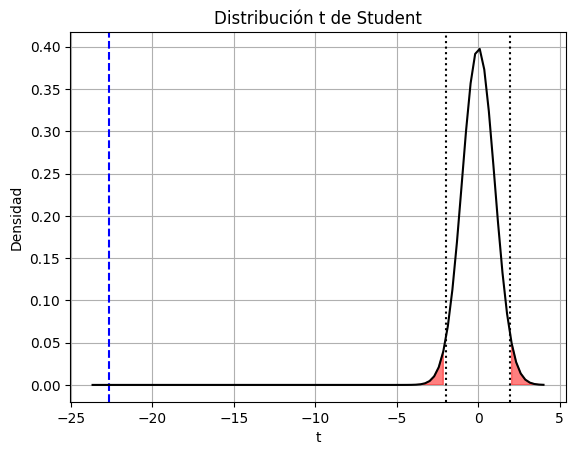

In [ ]:
PH1 = PH_VarianzaDesconocida(960, 959, 4627, 3, 0.05, 959, 'bi' )

### Análisis de Resultados

Aunque el valor reportado (960 millones) y el estimado con la base de datos (≈959 millones) son muy cercanos en términos prácticos, la prueba lo rechaza por dos razones clave:


*   **Tamaño de muestra muy grande (n = 4627):** Con tantos datos, la estimación de la media es muy precisa. Eso hace que incluso una diferencia pequeña (1 millón) se vuelva estadísticamente “visible”.
*   **Variabilidad relativamente baja (s ≈ 3 millones):** Al haber poca dispersión, el error estándar de la media es pequeño. Entonces, al calcular el estadístico de prueba, esa diferencia de 1 millón se traduce en un valor del error estándar tan pequeño y de t muy grande en magnitud (t≈−22.67), muy lejos de los puntos críticos (± 1.96).

El p-valor ≈ 0.000 significa: “Si la verdadera media fuera 960, la probabilidad de obtener una media muestral tan alejada como la que vimos (o más) es prácticamente cero.”

En la práctica 959 y 960 millones de dolares son casi iguales, pero desde el punto de vista estadístico, con muchos datos y poca variabilidad, esa diferencia tan pequeña es suficiente para rechazar H0, porque es muy improbable observar tal diferencia si la verdadera media fuera exactamente 960 millones.




##Prueba de hipótesis: Dos Muestras

En esta sección realizamos una prueba de hipótesis para comparar dos muestras independientes de la variable **FOBDOL**, que representa el valor de las exportaciones en millones de dólares. **El objetivo es analizar si el valor de exportaciones de Colombia hacia Estados Unidos en el mes de enero fue el mismo en los años 2023 y 2024**, o si existe evidencia estadística de un cambio entre estos dos periodos.

Dado que trabajamos con dos muestras grandes y se considera razonable asumir igualdad de varianzas, se utiliza una prueba de dos muestras para la diferencia de medias con varianza poblacional desconocida pero asumida igual. El contraste se plantea así:

$$
\begin{array}{cccc}
Enero\:\:2023:\:\:\:\:n1 = 4036 , & \overline{x}1 = 884\: Millones ,  & s1 = 3, & s1^2= 9
\end{array}
$$

$$
\begin{array}{cccc}
Enero\:\:2024:\:\:\:\:n2 = 4627  , & \overline{x}2 = 959\: Millones, & s2 = 3, & s2^2=9
\end{array}
$$

$$\alpha =0.05$$

$$
\begin{cases}
H_0: & \mu _1-\mu _2=0\:\:\:\:\rightarrow \:\:\:\:\mu _1=\mu _2 \\
H_a: & \mu _1-\mu _2\ne 0\:\:\:\:\rightarrow \:\:\:\:\mu _1\ne \mu _2
\end{cases}
\;\;\;\;\; \rightarrow \text{ Dos colas}
$$


In [ ]:
# Filtrar solo las filas donde COD_PAI4 == 'USA'
df_usa_2023_Enero = df_2023_Enero[df_2023_Enero['COD_PAI4'] == 'USA']

sum_fobdol_usa3 = df_usa_2023_Enero['FOBDOL'].sum()
desv_fobdol_usa3 = df_usa_2023_Enero['FOBDOL'].std()

print(f"✅ Número de registros para USA: {len(df_usa_2023_Enero)}")
print(f"✅ La sumatoria de FOBDOL (USA) es: {sum_fobdol_usa3:,.2f}")
print(f"✅ La desviación estándar muestral de FOBDOL (USA) es: {desv_fobdol_usa3:,.2f}")

✅ Número de registros para USA: 4036
✅ La sumatoria de FOBDOL (USA) es: 884,382,856.89
✅ La desviación estándar muestral de FOBDOL (USA) es: 3,097,113.37


Tipo de varianza: igual
Vaianza poblacional obtenida: sp2= 9.000
Desviación estándar a trabajar: sp= 3.000
Grados de libertad: v= 8661.000
Estadístico de prueba: zo= -1160.730

No se rechaza H₀ con nivel de significancia 0.050
Punto crítico: 1.645
P-Valor: 1.000
Beta: 0.950
Intervalo de confianza: [μ1-μ2 <=, -74.894]


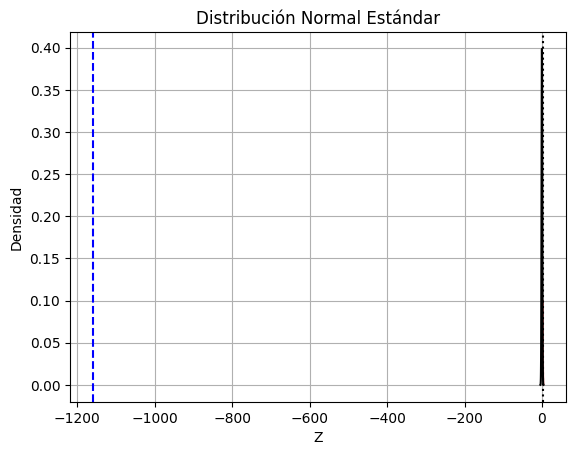

In [ ]:
#x1, x2, delta_0, delta_real, n1, n2, s1_2, s2_2, alfa, cola, tipo_desviación
PHDP_VarDesconocida(884, 959, 0, 0, 4036, 4627, 9, 9, 0.05, 'sup', 'igual')

### Análisis de Resultados
Los resultados de la prueba arrojan un estadístico de prueba muy extremo: z0​=−1160.730 Con un nivel de significancia α=0.05, los puntos críticos para una prueba de dos colas son aproximadamente ±1.960 y z0 es muchísimo mayor, el valor calculado cae muy lejos en la región de rechazo de H0. De forma consistente, el p-valor asociado es prácticamente 0.000, lo que indica que sería extremadamente improbable observar una diferencia muestral tan grande si en realidad las medias poblacionales fueran iguales.

**El intervalo de confianza es completamente negativo, lo que indica que, en promedio, el valor de FOBDOL en enero de 2024 es entre 74.873 y 75.127 millones de dólares mayor que en enero de 2023.** En otras palabras, los datos muestran una diferencia clara y consistente entre los dos años: las exportaciones hacia Estados Unidos en enero de 2024 fueron significativamente más altas que en enero de 2023.

En resumen, desde el punto de vista estadístico, los resultados indican que **no es razonable suponer que las medias de FOBDOL en 2023 y 2024 sean iguales.** La combinación de tamaños muestrales grandes, varianza relativamente baja y una diferencia amplia entre las medias genera un estadístico de prueba muy extremo, lo que respalda la conclusión de que las exportaciones en enero aumentaron de forma significativa de 2023 a 2024.

#<font color="green">Segunda fase de estudio:</font>

##Prueba de Bondad de Ajuste
Con base en el estudio del Banco de la República *Export Dynamics in Colombia: Firm-Level Evidence - Working Paper No. 446*, se propone realizar dos pruebas de bondad de ajuste simples, comparando distribuciones históricas con los datos actuales del proyecto.

Los enlaces a la información externa se dan a continuaciónn:

[Banco de la República de Colombia - Export Dynamics in Colombia: Firm-Level Evidence](https://www.banrep.gov.co/es/export-dynamics-colombia-firm-level-evidence)

[Borradores de economía - No 446](https://d1b4gd4m8561gs.cloudfront.net/sites/default/files/publicaciones/pdfs/borra446.pdf)

CITA:
Banco de la República. (2007). Export Dynamics in Colombia: Firm-Level Evidence. Borradores de Economía, No. 446. Disponible en: https://www.banrep.gov.co/sites/default/files/publicaciones/archivos/wp_446.pdf

La idea seria hacer dos pruebas de ajuste de bondad simple:


*   **Primera prueba:** Se analiza el comportamiento del valor FOB hacia Estados Unidos durante el periodo 2011–2024, contrastándolo con la distribución uniforme observada entre 1996 y 2005 (Figura 1 del estudio). Se plantea la hipótesis de que dicho patrón se mantiene en la década más reciente.
*   **Segunda prueba:** Se evalúa la cantidad de exportaciones hacia países latinoamericanos (Figura 5), considerando si los datos corresponden a un periodo de 10 años. Se propone que estas exportaciones presentan una distribución uniforme, sustentada en similitudes climáticas y comerciales que favorecen el intercambio de bienes entre estos países.


##Primera prueba: exportaciones de Colombia a EE.UU periodo 2011-2024

En esta primera prueba de bondad de ajuste se analiza el comportamiento del **valor FOB total exportado desde Colombia hacia Estados Unidos** durante el periodo **2011–2024**. El objetivo es comprobar si dicho valor sigue una **distribución uniforme en el tiempo**, tal como se observó históricamente para el periodo **1996–2005** en el estudio del Banco de la República *"Export Dynamics in Colombia: Firm-Level Evidence"*.


Con base en esta motivación, se formulan las siguientes hipótesis:


\begin{cases}
H_0: \text{El valor FOB hacia EE.UU. sigue una distribución uniforme} \\
\quad \quad \text{(no varía significativamente por año).} \\[6pt]
H_a: \text{El valor FOB hacia EE.UU. no sigue una distribución uniforme.}
\end{cases}

<br>

Se trabaja con un nivel de significancia de **$\alpha = 0.05\$**. Para contrastar estas hipótesis se emplea la prueba de bondad de ajuste chi-cuadrado, comparando las **frecuencias observadas (valor FOB total por año**) con las frecuencias esperadas bajo el supuesto de uniformidad (mismo valor promedio para cada año):


Estadístico Chi² = 4497854461155.0205
P-valor = 0.0000
 Se rechaza H₀ con α=0.05. La distribución NO es uniforme.


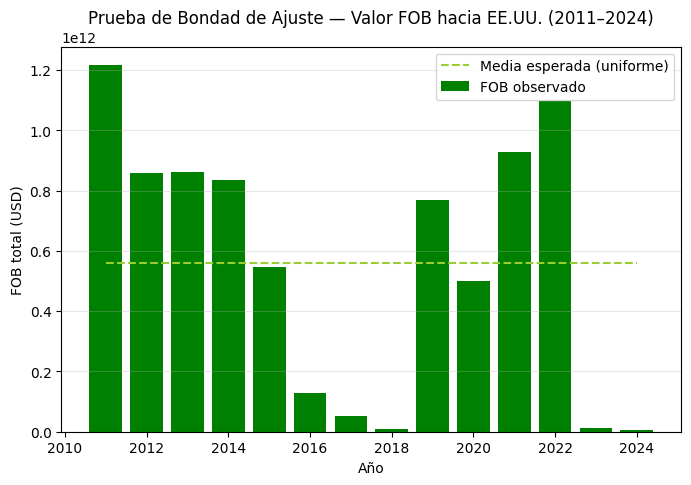

In [ ]:
# Filtrar exportaciones hacia Estados Unidos
df_usa = df_total[df_total['COD_PAI4'].isin(['USA', 'US', '840'])].copy()

# Agrupar por año y sumar el valor FOB
fob_usa = df_usa.groupby('ANHO')['FOBDOL'].sum()

# Número de categorías (años)
k = len(fob_usa)
# Esperado uniforme: promedio de todos los años
E = [fob_usa.mean()] * k

# Chi-cuadrado
chi2_stat, p_val = stats.chisquare(fob_usa, E)

print(f"\nEstadístico Chi² = {chi2_stat:.4f}")
print(f"P-valor = {p_val:.4f}")

# Decisión
alpha = 0.05
if p_val < alpha:
    print(f" Se rechaza H₀ con α={alpha}. La distribución NO es uniforme.")
else:
    print(f" No se rechaza H₀ con α={alpha}. La distribución podría ser uniforme.")

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(fob_usa.index, fob_usa.values, color='green', label='FOB observado')
plt.hlines(fob_usa.mean(), 2011, 2024, colors='yellowgreen', linestyles='--', label='Media esperada (uniforme)')
plt.title('Prueba de Bondad de Ajuste — Valor FOB hacia EE.UU. (2011–2024)')
plt.xlabel('Año')
plt.ylabel('FOB total (USD)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


### Análisis y conclusiones de la primera prueba

Al aplicar la prueba de bondad de ajuste chi-cuadrado a los datos de valor FOB hacia Estados Unidos en el periodo 2011–2024, se obtiene un estadístico de prueba muy elevado y un p-valor prácticamente nulo por lo que se **rechaza la hipótesis nula H0**.

En términos prácticos, esto significa que el valor total exportado hacia Estados Unidos presenta **variaciones muy marcadas entre años**, alejándose del patrón estable que se observaba en el periodo histórico 1996–2005. Algunos años muestran niveles de exportación considerablemente más altos y otros mucho más bajos que el valor promedio esperado bajo uniformidad, lo que genera un estadístico chi-cuadrado tan grande.

Por tanto, la conclusión estadística es que:

> **El valor FOB total exportado desde Colombia hacia Estados Unidos en el periodo 2011–2024 no sigue una distribución uniforme.**

Esto sugiere que, en la década más reciente, el comportamiento de las exportaciones hacia Estados Unidos ha estado influenciado por factores económicos, comerciales y posiblemente coyunturales (crisis, cambios en demanda, variaciones en precios internacionales, etc.), que han generado **fluctuaciones significativas** año a año y han roto el patrón de estabilidad observado en el periodo histórico analizado por el Banco de la República.

##Segunda prueba: exportaciones de Colombia a latinoamérica 2011-2024
En esta segunda prueba de bondad de ajuste **se analiza el comportamiento del valor FOB total exportado desde Colombia hacia países latinoamericanos **durante un periodo de 10 años (2014–2023). El objetivo es evaluar si la distribución del valor exportado entre estos países puede considerarse uniforme, es decir, si en promedio cada país recibe un nivel similar de exportaciones en términos de FOB.

La motivación de esta es porque en el estudio ya mencionado vemos que en la Figura 5 en el periodo de 1996 - 2005 las exportaciones hacia estos países si siguieron una distribución relativamente normal, por lo que queremos analizar si en los siguientes años sigue sosteniendose esta uniformidad, por lo que se plantea:

\begin{cases}
H_0: \text{El valor FOB hacia paises de latinoamerica sigue una distribución uniforme} \\
\quad \quad \text{(no varía significativamente por año).} \\[6pt]
H_a: \text{El valor FOB hacia paises de latinoamerica no sigue una distribución uniforme.}
\end{cases}


Estadístico Chi² = 7895769624718.4111
P-valor = 0.0000
 Se rechaza H₀ con α=0.05. Las exportaciones NO son uniformes entre países latinoamericanos.


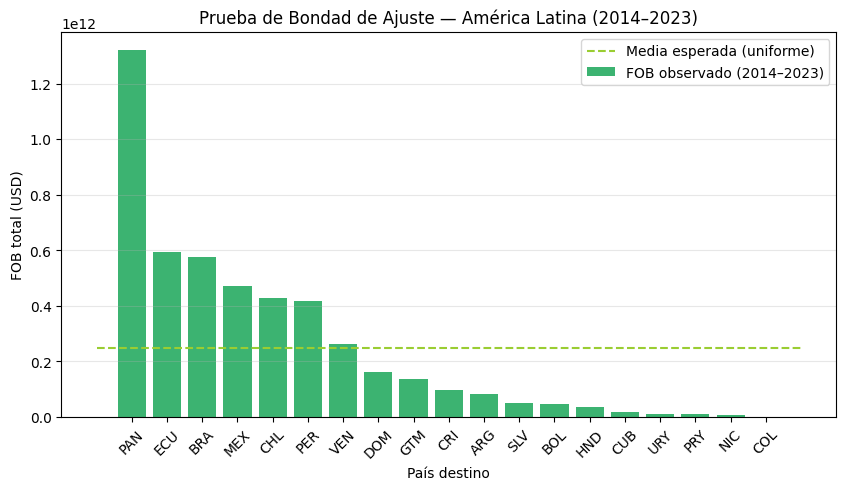

In [ ]:
# ===Filtrar periodo de 10 años (2014-2023) ===
df_10y = df_total[(df_total['ANHO'] >= 2014) & (df_total['ANHO'] <= 2023)].copy()

# === Definir lista de países latinoamericanos ===
latam_countries = [
    'ARG', 'BOL', 'BRA', 'CHL', 'COL', 'CRI', 'CUB', 'DOM', 'ECU', 'GTM', 'HND',
    'MEX', 'NIC', 'PAN', 'PRY', 'PER', 'SLV', 'URY', 'VEN'
]

# === Filtrar exportaciones hacia LATAM ===
df_latam = df_10y[df_10y['COD_PAI4'].isin(latam_countries)].copy()

# === Agrupar por país y sumar valor FOB ===
fob_latam = df_latam.groupby('COD_PAI4')['FOBDOL'].sum().sort_values(ascending=False)

# ===  Prueba de bondad de ajuste (Chi-cuadrado) ===
k = len(fob_latam)
E = [fob_latam.mean()] * k

chi2_stat2, p_val2 = stats.chisquare(fob_latam, E)
alpha = 0.05

print(f"\nEstadístico Chi² = {chi2_stat2:.4f}")
print(f"P-valor = {p_val2:.4f}")

if p_val2 < alpha:
    print(f" Se rechaza H₀ con α={alpha}. Las exportaciones NO son uniformes entre países latinoamericanos.")
else:
    print(f" No se rechaza H₀ con α={alpha}. Las exportaciones pueden considerarse uniformes en este periodo de 10 años.")

# === Grafico ===
plt.figure(figsize=(10,5))
plt.bar(fob_latam.index, fob_latam.values, color='mediumseagreen', label='FOB observado (2014–2023)')
plt.hlines(fob_latam.mean(), -1, k, colors='yellowgreen', linestyles='--', label='Media esperada (uniforme)')
plt.title('Prueba de Bondad de Ajuste — América Latina (2014–2023)')
plt.xlabel('País destino')
plt.ylabel('FOB total (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


###Análisi y conclusiones
Al aplicar la prueba de bondad de ajuste chi-cuadrado a los datos de exportaciones hacia países latinoamericanos en el periodo 2014–2023, se obtiene un estadístico chi-cuadrado muy elevado y un p-valor prácticamente nulo.

Dado que p<α=0.05, se rechaza la hipótesis nula H0. Es decir, **los resultados indican que el valor FOB no se reparte de forma uniforme entre los países latinoamericanos considerados.**

En términos prácticos, esto significa que algunos países reciben volúmenes de exportación considerablemente mayores que otros, alejándose del escenario idealizado de equilibrio entre destinos. El gráfico de barras refuerza esta idea al mostrar países que concentran gran parte del valor exportado, mientras que otros tienen montos relativamente pequeños frente al promedio esperado bajo uniformidad

Este resultado sugiere que, pese a las similitudes regionales y ciertas condiciones compartidas, **en la práctica existen diferencias importantes en la intensidad comercial con cada país**, posiblemente asociadas a factores como el tamaño de cada economía, acuerdos bilaterales específicos, estructuras productivas complementarias, cercanía geográfica efectiva, costos logísticos y preferencias del mercado. Estas diferencias se reflejan en un patrón de exportaciones claramente concentrado en algunos destinos clave y no en una distribución homogénea en toda la región.

###Pequeño experimento

Parámetros Lognormal ajustados: shape=1.749, loc=0.000, scale=84651060805.407

Estadístico Chi² = 3478990230779.0498
P-valor = 0.0000
 Se rechaza H₀ con α=0.05. Los datos NO siguen la distribución Lognormal.


/tmp/ipython-input-2514838895.py:48: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(fob_latam.index, E_lognorm, 'ro--', color='yellowgreen', label='Esperado según Lognormal')


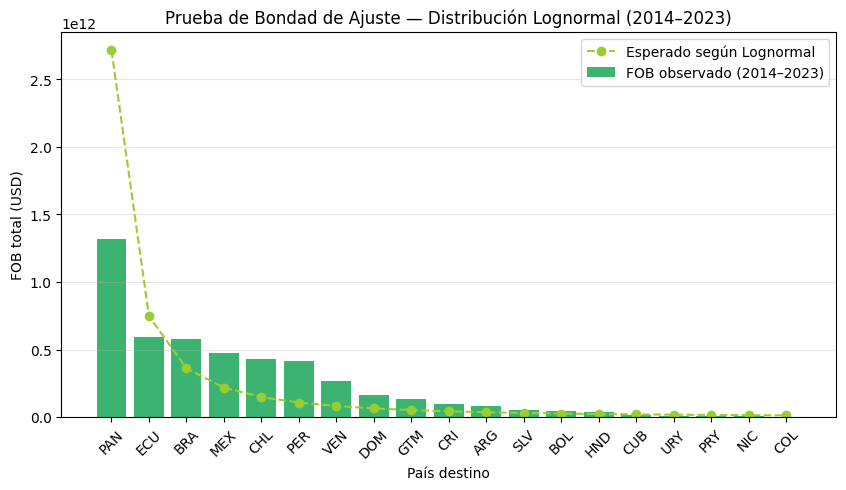

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import lognorm

# === Filtrar periodo de 10 años (2014-2023) ===
df_10y = df_total[(df_total['ANHO'] >= 2014) & (df_total['ANHO'] <= 2023)].copy()

# === Definir lista de países latinoamericanos ===
latam_countries = [
    'ARG', 'BOL', 'BRA', 'CHL', 'COL', 'CRI', 'CUB', 'DOM', 'ECU', 'GTM', 'HND',
    'MEX', 'NIC', 'PAN', 'PRY', 'PER', 'SLV', 'URY', 'VEN'
]

# === Filtrar exportaciones hacia LATAM ===
df_latam = df_10y[df_10y['COD_PAI4'].isin(latam_countries)].copy()

# === Agrupar por país y sumar valor FOB ===
fob_latam = df_latam.groupby('COD_PAI4')['FOBDOL'].sum().sort_values(ascending=False)

# === Ajustar distribución Lognormal a los datos ===
shape, loc, scale = lognorm.fit(fob_latam.values, floc=0)  # forzamos loc=0 porque FOB ≥ 0
print(f"Parámetros Lognormal ajustados: shape={shape:.3f}, loc={loc:.3f}, scale={scale:.3f}")

# === Calcular valores esperados según Lognormal ===
x_vals = np.linspace(min(fob_latam.values), max(fob_latam.values), len(fob_latam))
pdf_vals = lognorm.pdf(x_vals, shape, loc=loc, scale=scale)

# Escalar a frecuencias esperadas (mismo total que observado)
E_lognorm = pdf_vals / pdf_vals.sum() * fob_latam.sum()

# === Prueba Chi-cuadrado ===
chi2_stat, p_val = stats.chisquare(fob_latam.values, E_lognorm)
alpha = 0.05

print(f"\nEstadístico Chi² = {chi2_stat:.4f}")
print(f"P-valor = {p_val:.4f}")

if p_val < alpha:
    print(f" Se rechaza H₀ con α={alpha}. Los datos NO siguen la distribución Lognormal.")
else:
    print(f" No se rechaza H₀ con α={alpha}. Los datos pueden considerarse ajustados a la distribución Lognormal.")

# === Gráfico ===
plt.figure(figsize=(10,5))
plt.bar(fob_latam.index, fob_latam.values, color='mediumseagreen', label='FOB observado (2014–2023)')
plt.plot(fob_latam.index, E_lognorm, 'ro--', color='yellowgreen', label='Esperado según Lognormal')
plt.title('Prueba de Bondad de Ajuste — Distribución Lognormal (2014–2023)')
plt.xlabel('País destino')
plt.ylabel('FOB total (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#<font color="green">Tercera fase de estudio:</font>


##Pruebas de Regresión Lineal con nuestra DB


En esta sección se aplica un modelo de regresión lineal simple para estudiar la relación entre dos variables importantes de la base de datos de exportaciones:


*   **PNK**: peso neto de la carga exportada.
*   **FOBDOL**: valor de la mercancía en dólares.

La idea es analizar si, **a medida que aumenta el peso neto de la carga, también aumenta el valor FOB de forma aproximadamente lineal**, y en qué medida esa relación es fuerte o débil. Es decir, buscamos responder a una pregunta del tipo: “¿el valor de la exportación crece de manera proporcional al peso de lo que se envía?”.

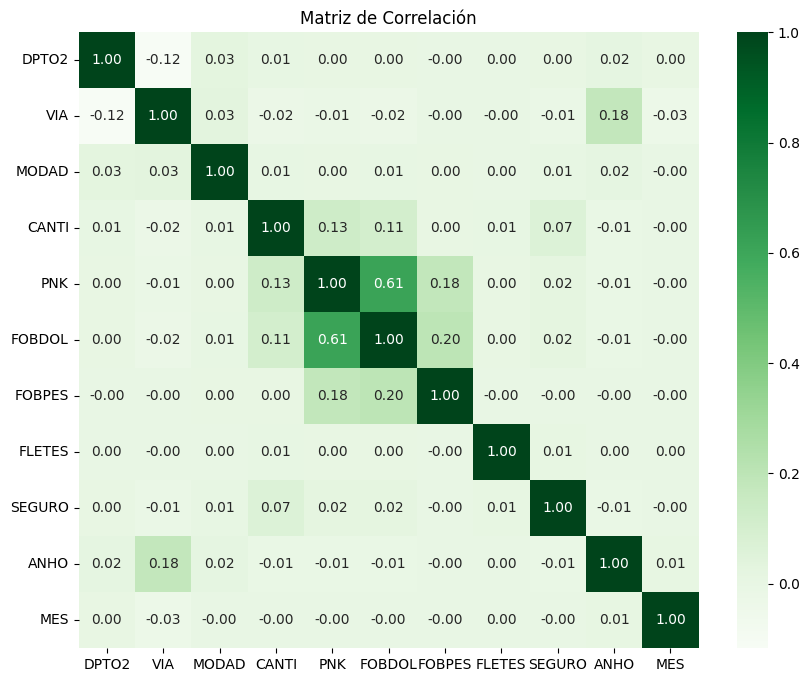

In [ ]:
#Matriz de correlacion
df_numericos = df_total.select_dtypes(include=np.number)
matriz_correlacion = df_numericos.corr()

#Grafica
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='Greens', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

Para **reducir la variabilidad y centrarnos en un mercado específico**, se decidió trabajar únicamente con las exportaciones hacia **Estados Unidos en enero de 2024**, filtrando la base de datos a las filas donde COD_PAI4 == 'USA' y tomando solo las columnas PNK y FOBDOL. Además, se realizó una limpieza previa eliminando valores faltantes (NaN) y filas con ceros, con el fin de garantizar que la estimación del modelo se apoye en registros completos y consistentes.

A partir de este subconjunto, se construyó el modelo de regresión lineal donde **PNK** actúa como **variable independiente (X)** y **FOBDOL** como **variable dependiente (Y)**, permitiendo estimar una recta, que represente, de manera aproximada, cómo cambia el valor FOB cuando varía el peso neto de las exportaciones hacia Estados Unidos.

In [ ]:
# ========== Eliminamos todos los valores de NaN y 0´s ==========
# Forma 2: inplace (modifica el original directamente)
df_2024_Enero.dropna(inplace=True)  # Borra filas con NaN ✅

# Eliminar filas donde CUALQUIER columna tenga valor 0
df_2024_Enero = df_2024_Enero[(df_2024_Enero != 0).all(axis=1)]

print(f"Registros después de limpieza: {len(df_2024_Enero)}")

Registros después de limpieza: 6426


In [ ]:
# Filtrado de ESTADOS UNIDO
df_2024_Enero_usa_pnk_fobdol = df_2024_Enero[df_2024_Enero['COD_PAI4'] == 'USA'][[' PNK ', ' FOBDOL ']].copy()
print(f"Registros después de limpieza: {len(df_2024_Enero_usa_pnk_fobdol)}")

Registros después de limpieza: 876


In [ ]:
# Convertir a vectores para tu función
vector_PNK = df_2024_Enero_usa_pnk_fobdol[' PNK '].to_numpy()
vector_FOBDOL = df_2024_Enero_usa_pnk_fobdol[' FOBDOL '].to_numpy()

print(f"Elementos para regresión: {len(vector_PNK)}")

Elementos para regresión: 876


In [ ]:
R2= RegresionLineal(vector_PNK, vector_FOBDOL,0.05, 0)



📌 Resultados de la regresión lineal:
→ sum_x2 es: 8057691778282.794
→ x_barra es:  19467.166689497717
→→→→ Recta de regresión:  126572.9323749768 + 2.5543991662130288 x
------------------------------------------------------------------
→ Punto de corte (B0): 126572.9324
→ Pendiente (B1): 2.5544
------------------------------------------------------------------
→ Suma de cuadrados (SSE): 7169563085017493.0000
→ Estimación de la varianza del error (σ̂²): 8203161424505.1406
→ Desviación estándar del error (σ): 2864116.1681
→ Varianza de B1: 1.061799841554077
→ Varianza de B0: 9766730426.3382
→ Desviación estándar de B1: 1.0304
→ Covarianza entre B1 y B0: -20670.234506
------------------------------------------------------------------
→ Punto critico 1.9626819524828751
→ Intervalo de confianza de B1: [0.5320, & , 4.5768]
------------------------------------------------------------------
La cota superior para Y es:  5751267.454932155
La cota inferior para Y es:  -5498121.590182202
La esti

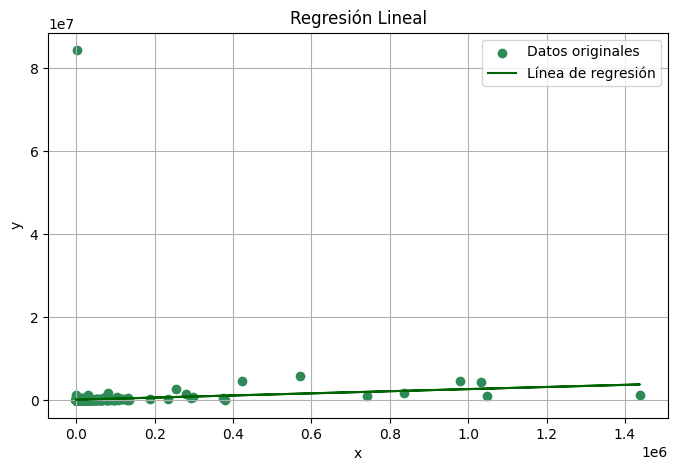

In [ ]:
graficar_RL(vector_PNK, vector_FOBDOL,R2[0])

En la primera ejecución de la regresión lineal con todos los datos disponibles para Estados Unidos, se observó que la nube de puntos estaba **extremadamente concentrada alrededor del origen**, formando una especie de “tumulto” de valores pequeños, mientras que unos pocos registros muy grandes (del orden de
10^8) quedaban aislados y dominaban la escala del gráfico y los cálculos.

Este comportamiento es típico cuando existen **valores atípicos o extremos (outliers) que representan operaciones de exportación muy grandes, poco frecuentes, pero con montos y pesos desproporcionadamente altos frente al resto**. En estos casos, el modelo de regresión ajustado a todos los datos termina siendo “arrasado” por esos valores extremos: afecta la pendiente, el intercepto, la estimación del error y, sobre todo, dificulta la visualización e interpretación de lo que pasa con las exportaciones más comunes.

Por ese motivo se tomó la decisión de **limitar el análisis** a observaciones con valores menores o iguales a 10^5 tanto en PNK como en FOBDOL. Este umbral (1×10^5) se eligió como una forma de “recortar la escala” para:


*   Enfocarse en el rango donde se concentran la mayoría de las operaciones reales y cotidianas.
*   Evitar que unas pocas exportaciones gigantes distorsionen la percepción de la relación entre peso y valor.
*   Obtener un modelo de regresión más representativo del comportamiento típico de las exportaciones, y no de casos excepcionales.

En otras palabras, **el recorte no se hace para “maquillar” los datos, sino para analizar con más claridad el patrón general de las exportaciones habituales**, dejando a un lado operaciones extremadamente grandes que podrían requerir un tratamiento específico o un modelo diferente.





📌 Resultados de la regresión lineal:
→ sum_x2 es: 93112100893.1676
→ x_barra es:  4742.808792650919
→→→→ Recta de regresión:  11251.014017931448 + 1.420598226395197 x
------------------------------------------------------------------
→ Punto de corte (B0): 11251.0140
→ Pendiente (B1): 1.4206
------------------------------------------------------------------
→ Suma de cuadrados (SSE): 274089959311.1893
→ Estimación de la varianza del error (σ̂²): 360644683.3042
→ Desviación estándar del error (σ): 18990.6473
→ Varianza de B1: 0.004747105342235087
→ Varianza de B0: 580069.4903
→ Desviación estándar de B1: 0.0689
→ Covarianza entre B1 y B0: -22.514613
------------------------------------------------------------------
→ Punto critico 1.9630902864779947
→ Intervalo de confianza de B1: [1.2853, & , 1.5559]
------------------------------------------------------------------
La cota superior para Y es:  48561.33844460426
La cota inferior para Y es:  -26059.310408741367
La estimación (cuando u

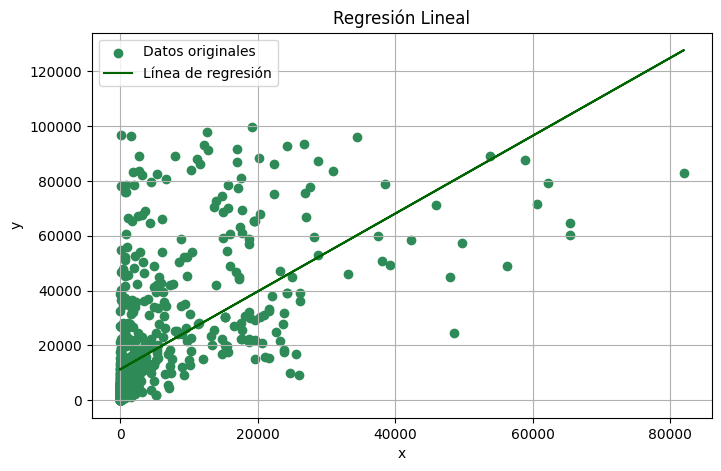

In [ ]:
umbral = 1e5

# Filtrado
df_filtrado = df_2024_Enero_usa_pnk_fobdol[
    (df_2024_Enero_usa_pnk_fobdol[' PNK '] <= umbral) &
    (df_2024_Enero_usa_pnk_fobdol[' FOBDOL '] <= umbral)
].copy()

#Convertir a vectores
vector_PNK_filtrado = df_filtrado[' PNK '].to_numpy()
vector_FOBDOL_filtrado = df_filtrado[' FOBDOL '].to_numpy()

R2_filtrado = RegresionLineal(vector_PNK_filtrado, vector_FOBDOL_filtrado, 0.05, 0)
graficar_RL(vector_PNK_filtrado, vector_FOBDOL_filtrado, R2_filtrado[0])


Al repetir la regresión lineal usando únicamente las observaciones con **PNK** $\le 10^5$ y **FOBDOL** $\le 10^5$, el comportamiento del modelo mejora notablemente y se vuelve más coherente con lo que sugería la matriz de correlación.

El modelo ajustado tiene la forma:
$$y=11251.01+1.4206x$$
Donde:


*   $B0\:\approx 11251.01$ representa el valor FOB estimado cuando el peso neto es muy pequeño (interpretado como un nivel base de valor asociado a costos mínimos, empaques, seguros, etc.).
*   $B1\:\approx 1.4206$ indica que, por cada unidad adicional de PNK, el valor FOB aumenta en promedio 1.42 dólares, dentro del rango analizado.

El intervalo de confianza para la pendiente es aproximadamente:
$$B1\:\in \left[1.2853\:,\:1.5559\right]$$

lo que significa que el efecto del peso sobre el valor FOB es **estadísticamente significativo** (el intervalo no incluye 0) y relativamente estable: siempre se mantiene alrededor de 1.3–1.5 dólares adicionales por unidad de peso.

Por otra parte, la correlación entre PNK y FOBDOL en este subconjunto es: $r\approx 0.599$ lo que coincide mucho mejor **con la correlación media (~0.61)** observada en la matriz inicial. **Esto nos dice que existe una relación lineal moderadamente fuerte y positiva: a mayor peso de la carga, mayor valor de la exportación**, aunque no es una relación perfecta (también influyen el tipo de producto, el precio por kilo, el valor agregado, etc.).

Como conclusión, dentro del rango de exportaciones “normales” (sin valores extremos), podemos afirmar que el peso neto es un buen predictor del valor FOB hacia Estados Unidos en enero de 2024, y que la regresión lineal simple es una herramienta adecuada para describir esta relación en ese contexto.


#<font color="green">Cuarta fase de estudio:</font>
##Regresión Lineal con Transformadas
En esta fase aplicamos una regresión lineal con transformaciones logarítmicas para mejorar el ajuste entre el peso neto (PNK) y el valor de las exportaciones (FOBDOL). En lugar de trabajar directamente con los datos originales, transformamos la relación usando un modelo de potencia.

Esto nos permite ajustar una recta en la escala (ln(x),ln(y)) y luego volver al espacio original, obteniendo una curva que captura mejor el comportamiento no lineal de los datos, especialmente cuando la relación entre peso y valor crece de forma desacelerada.

===== Transformada de potencia =====
Mi recta de regresión es: ln(y) = 5.41460 + 0.53846·ln(x)
B0 = 5.41460  y B1 = 0.53846
y estimado con z = 1= 224.66231


simga_2 = 1.56602
simga = 1.25141


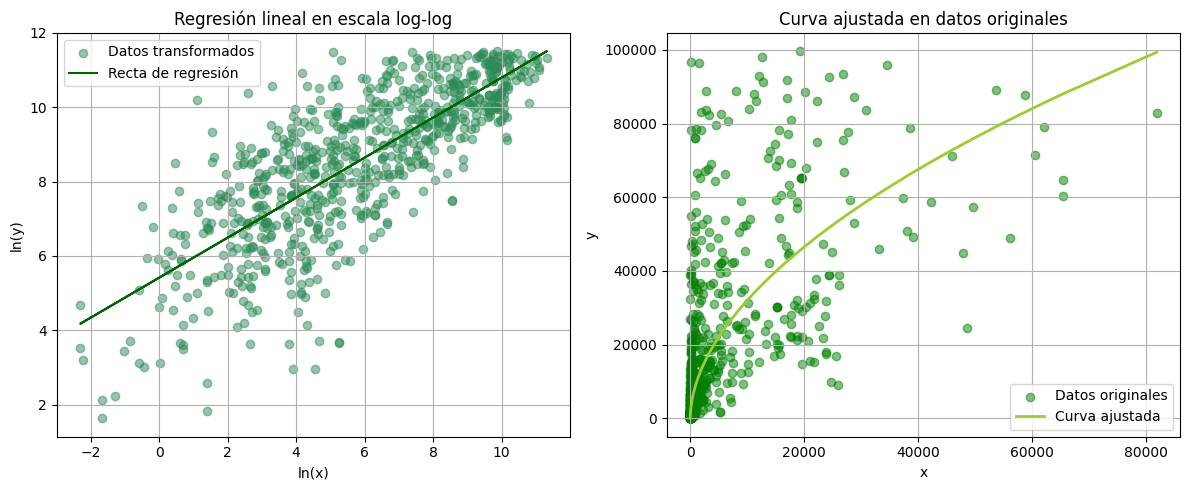

In [ ]:
# Aplicar regresión
RP2 = regresion_potencia(vector_PNK_filtrado, vector_FOBDOL_filtrado, z=1)

###Análisis y breves conclusiones
El exponente $\beta \approx 0.54$ **sugiere que el valor FOB sí aumenta con el peso**, pero a un ritmo sublineal (menos que proporcional). En otras palabras, cuando el peso de la carga crece, el valor también crece, pero cada kilo adicional aporta relativamente menos valor que los anteriores (posible efecto de economías de escala, costos fijos, etc.).

La gráfica en escala log–log muestra una nube de puntos más alineada con la recta de regresión, y la curva ajustada sobre los datos originales refleja mejor la forma real del patrón: una subida rápida al inicio que luego se “suaviza”. En conjunto, la transformación de potencia entrega un modelo más realista para describir la relación peso–valor en este rango de exportaciones.

## Series de Tiempo

##Primera serie:
En esta última parte del análisis se construye una serie de tiempo a partir del **valor FOBDOL promedio mensual de las exportaciones de Colombia, sin distinguir país de destino, para el periodo enero de 2011 a diciembre de 2024.**

Para ello se crea una fecha a partir del año y el mes de cada registro, se filtran valores válidos y luego se calcula el promedio mensual de FOBDOL, obteniendo así una serie que resume cómo ha evolucionado en el tiempo el valor de las exportaciones (en dólares estadounidenses).

El objetivo de esta gráfica no es hacer un modelo de predicción complejo, sino **explorar el comportamiento temporal**: identificar tendencias generales, picos, caídas abruptas y periodos con valores inusualmente bajos, y relacionarlos de forma cualitativa con posibles eventos económicos o coyunturales que hayan podido afectar el comercio exterior colombiano durante estos años.

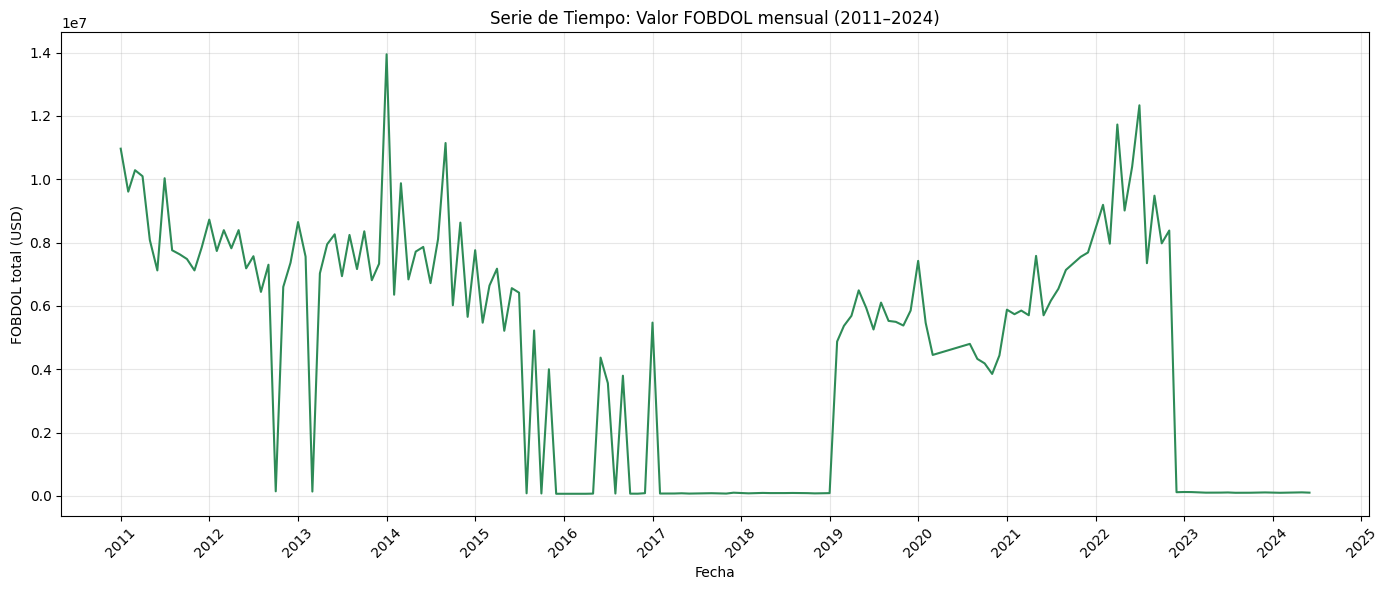

In [ ]:
# Crear columna de fecha correctamente
df_fob = df_total.copy()
df_fob_fecha = df_fob[['ANHO', 'MES']].rename(columns={'ANHO': 'year', 'MES': 'month'})
df_fob_fecha['day'] = 1
df_fob['FECHA'] = pd.to_datetime(df_fob_fecha, errors='coerce')

# Filtrar fechas válidas y FOBDOL no nulos
df_fob = df_fob[(df_fob['FECHA'].notna()) & (df_fob['FOBDOL'].notna())]

# Agrupar por fecha mensual
serie_fob = df_fob.groupby('FECHA')['FOBDOL'].mean()

# Graficar serie de tiempo
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))
plt.plot(serie_fob.index, serie_fob.values, color='seagreen')
plt.title('Serie de Tiempo: Valor FOBDOL mensual (2011–2024)')
plt.xlabel('Fecha')
plt.ylabel('FOBDOL total (USD)')
plt.grid(True, alpha=0.3)

# Mostrar todos los años en el eje X
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###Analisis de Resultados
En los primeros años (**2011–2014**) se ve un nivel relativamente **alto y fluctuante, con algunos picos marcados**, lo que puede estar asociado a **buenos precios internacionales** de ciertos productos de exportación (como petróleo, carbón o bienes mineros) y a un contexto externo relativamente favorable.

A partir de 2015 y especialmente entre **2016 y 2017**, aparecen meses con **valores muy bajos** en comparación con el resto de la serie. No son exactamente cero, pero sí están muy por debajo del nivel típico de los años anteriores. Esto **podría relacionarse con la caída de los precios del petróleo y otros choques externos** que afectaron los ingresos por exportaciones en esa época, así como ajustes en la economía local.

Entre **2019 y 2022 se observa una recuperación con niveles nuevamente más altos** (aunque con variabilidad), donde destacan varios picos pronunciados. En este periodo también inciden **factores como la pandemia de COVID-19 (2020–2021)**, que alteró cadenas logísticas, demanda mundial y precios, generando meses de **alta actividad dada a la gran globalización de mercados online, entregas a domicilio y plataformas internacionales**

Hacia el final de la serie, aproximadamente entre** 2023 y 2024,** vuelven a aparecer **valores promedio mensuales muy pequeños** respecto a los máximos de la gráfica. Esto puede interpretarse como una combinación de factores: cambios en los precios internacionales, posibles variaciones en la composición de la canasta exportadora, efectos de la política económica interna o de la demanda externa, e incluso decisiones empresariales que desplazan ciertos flujos comerciales hacia otros mercados o productos.

En conjunto,** la serie muestra que el comportamiento del valor FOBDOL no es estable ni uniforme: está fuertemente influenciado por choques externos **(precios internacionales, crisis globales, pandemia) y por dinámicas internas de la economía colombiana. Los tramos con valores muy bajos resaltan justamente esos periodos de tensión o cambio, mientras que los picos representan momentos de alto dinamismo exportador.

*El análisis de la serie de tiempo confirma que las exportaciones colombianas, medidas por el valor FOBDOL mensual, siguen un patrón altamente variable y sensible al contexto económico, lo cual es coherente con la dependencia de ciertos sectores clave y con la exposición del país a las condiciones del comercio internacional.*

##Segunda serie:
En esta segunda serie de tiempo se analiza **la frecuencia mensual de exportaciones desde Colombia hacia Estados Unidos entre enero de 2011 y diciembre de 2024.** Para ello, se filtran los registros cuyo destino es EE.UU. y luego se cuenta el** número de operaciones de exportación por mes**.

A diferencia de la serie anterior (basada en valor FOB), aquí no miramos cuánto dinero se exporta, sino cuántas exportaciones se realizan en cada periodo. Esta perspectiva **permite estudiar el dinamismo comercial en términos de volumen de operaciones**, identificar tendencias a lo largo de los años y detectar periodos con aumentos o caídas abruptas en la actividad exportadora hacia este socio clave.

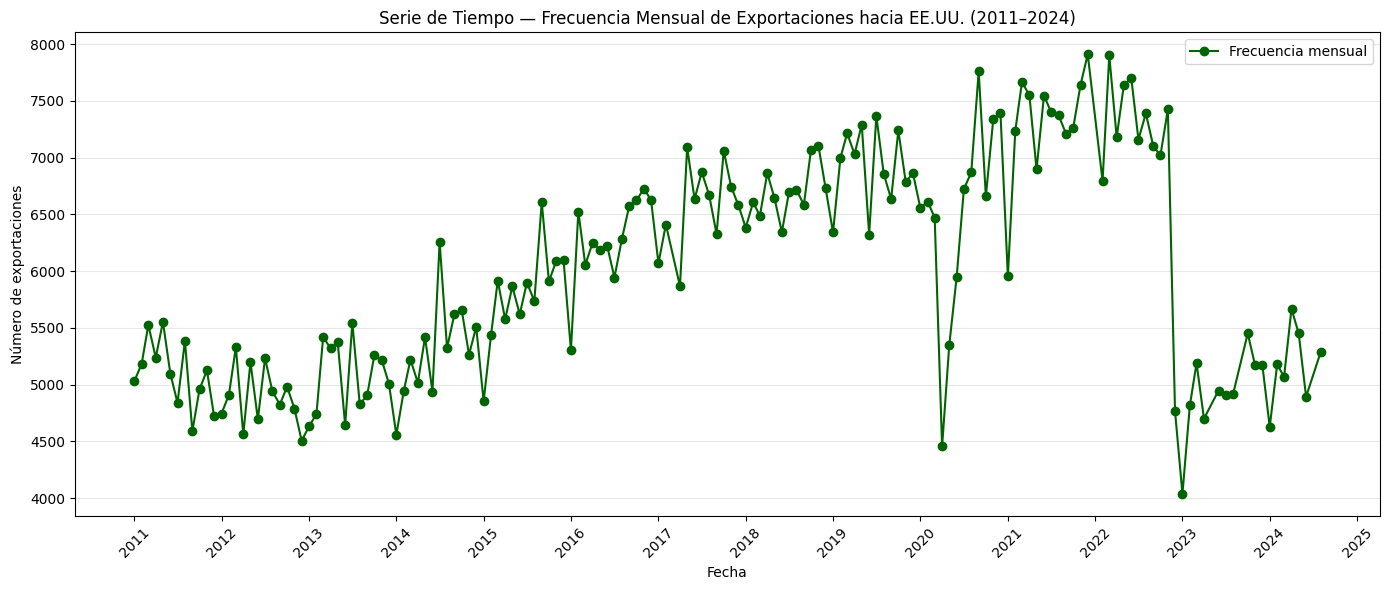

In [ ]:
# Filtrar exportaciones hacia EE.UU.
df_usa = df_total[df_total['COD_PAI4'].isin(['USA', 'US', '840'])].copy()

# Crear columna de fecha (primer día de cada mes)
df_usa_fecha = df_usa[['ANHO', 'MES']].rename(columns={'ANHO': 'year', 'MES': 'month'})
df_usa_fecha['day'] = 1
df_usa['FECHA'] = pd.to_datetime(df_usa_fecha, errors='coerce')

# Filtrar fechas válidas
df_usa = df_usa[df_usa['FECHA'].notna()]

# Agrupar por fecha mensual y contar registros
freq_mensual_usa = df_usa.groupby('FECHA').size()

import matplotlib.dates as mdates

plt.figure(figsize=(14,6))
plt.plot(freq_mensual_usa.index, freq_mensual_usa.values, marker='o', color='darkgreen', label='Frecuencia mensual')
#plt.hlines(freq_mensual_usa.mean(), freq_mensual_usa.index.min(), freq_mensual_usa.index.max(),colors='red', linestyles='--', label='Media mensual')

plt.title('Serie de Tiempo — Frecuencia Mensual de Exportaciones hacia EE.UU. (2011–2024)')
plt.xlabel('Fecha')
plt.ylabel('Número de exportaciones')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar todos los años en el eje X
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

La serie muestra una **tendencia creciente clara desde 2011 hasta alrededor de 2021–2022**: el número de exportaciones mensuales hacia EE.UU. va subiendo de forma bastante marcada, con fluctuaciones normales (picos y valles) pero manteniendo un nivel cada vez más alto. Esto **sugiere un proceso de fortalecimiento progresivo del comercio con Estados Unidos durante más de una década.**

Sin embargo, hacia f**inales de 2022 se observa una caída abrupta** en la frecuencia de exportaciones, seguida de niveles significativamente más bajos durante 2023 y 2024, comparables a los de 2011–2013. Esta ruptura de la tendencia puede estar asociada a varios factores combinados:

*   Reducción en las ventas del sector minero-energético, que incluyen petróleo, carbón y minerales, que cayeron más de un 15,5% en algunas mediciones.
*   La sequía en el Canal de Panamá provocó tiempos de espera más largos para los barcos, aumentando los costos y los tiempos de envío, lo que impactó negativamente las exportaciones.
*   Algunos informes señalan que la incertidumbre generada por políticas gubernamentales también pudo haber afectado las decisiones de exportación.

La serie sugiere dos etapas bien diferenciadas: una fase de expansión sostenida hasta 2022 y, luego, un retroceso en la intensidad de las exportaciones hacia EE.UU., que rompe la tendencia creciente y devuelve la frecuencia mensual a niveles similares a los del inicio del periodo analizado.
